In [1]:
from utils.motif import init_repro

init_repro(42, deterministic=True)

import sys
import os
sys.path.append(os.path.abspath("./utils"))

from utils.explanations import (
    render_explained_video_small_tl,
    explain_instance,
    plot_attention_heatmaps,
    print_explanation_with_labels,
)
import matplotlib.pyplot as plt

import pickle

import clip

## Loading of MoTIF Checkpoint

In [2]:
dataset = "hmdb51"

clip_model = "l14"  # res50, b16, b32, l14, siglip, clip4clip

if dataset == "breakfast":
    dataset_name = "Breakfast"
elif dataset == "ucf101":
    dataset_name = "UCF101"
elif dataset == "hmdb51":
    dataset_name = "HMDB"
elif dataset == "something2":
    dataset_name = "Something2"
else:
    print(f"{dataset} not found")

model_name = f"./Models/checkpoint_{clip_model}_{dataset_name}.pkl"

if os.path.exists(model_name):
    try:
        with open(model_name, "rb") as f:
            cbm_model = pickle.load(f)
            print("Loaded existing MoTIF model from", model_name)
    except FileNotFoundError:
        print("MoTIF file not found, creating a new one.")

Loaded existing MoTIF model from ./Models/checkpoint_l14_HMDB.pkl


## Print Global and Local top-k Explanations

In [3]:
# Build once from your training cell
label_decoder = cbm_model.encoder  # the fitted LabelEncoder

# Pick an example
i = 1 # define a number in the test set
video = cbm_model.X_test[i] # you can also switch to the train set
true_idx = cbm_model.y_test[i]
vid_path = cbm_model.paths_test[i]

# Explain
res = explain_instance(cbm_model.model, video)
print_explanation_with_labels(
    res,
    cbm_model.video_spans[vid_path],
    label_decoder=label_decoder,
    true_label_idx=true_idx,
    concepts_list=cbm_model.concepts.text_concepts,
    top_k_times=5, # how many local concept windows
    top_k_concepts=4, # how many top-k concepts per window
)

Predicted: 0 (brush_hair) | True: 0 (brush_hair)
Target class: 0

Top concepts (global):
  hair                           +2.434  ████████████████████
  grab                           +1.927  ████████████████····
  comb                           +1.193  ██████████··········
  brush                          +1.133  █████████···········

Important time steps:
  t=[00:08.27 - 00:08.50] time_importance=0.017  TI[████████████████████]  Score[████████████████████]
     - hair                           +2.366  ████████████████████
     - brush                          +1.934  ████████████████····
     - grab                           +1.796  ███████████████·····
     - comb                           +1.311  ███████████·········
  t=[00:05.60 - 00:05.83] time_importance=0.016  TI[██████████████████··]  Score[██████████████████··]
     - hair                           +2.393  ████████████████████
     - grab                           +1.936  ████████████████····
     - brush                    

## Temporal Dependency Plot

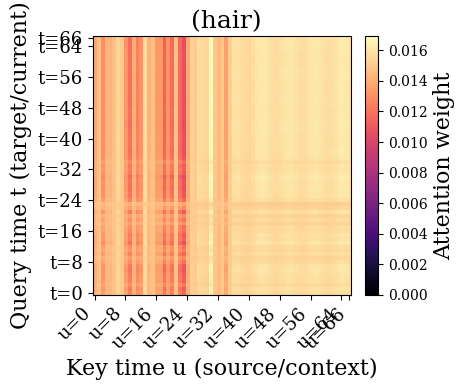

[<Figure size 500x400 with 2 Axes>]

In [4]:
def get_id(list, text):
    for i, item in enumerate(list):
        if item == text:
            return i
    print("Concept not included!")
    return 0


concept_idx = get_id(
    cbm_model.concepts.text_concepts, "hair"
)  # change concept name to find index in concept set

plot_attention_heatmaps(
    res,
    concept_idx=concept_idx,
    concept_names=cbm_model.concepts.text_concepts,
    layer_agg="mean",
    show_seconds=True,
    savepath=None,
)

## (Optional) Save Video

**Important**: This only works if you have correctly defined all paths and saved the videos as mp4 in the Dataset folder. Please follow our instructions.

In [ ]:
video = cbm_model.X_test[i] 
true_idx = cbm_model.y_test[i]
vid_path = cbm_model.paths_test[i].replace("../", "./")
print("Video path:", vid_path)

# Explain (same as your code)
res = explain_instance(cbm_model.model, video)
out_mp4 = render_explained_video_small_tl(
    vid_path=vid_path,
    out_path=f"./Videos/{dataset}_{i}.mp4",
    res=res,
    fps_frame_seconds=cbm_model.video_spans[vid_path],
    label_decoder=label_decoder,
    true_label_idx=true_idx,
    concepts_list=cbm_model.concepts.text_concepts,
    up_scale=2.0,  # 2x upscaling
    top_k_times=0,  
    top_k_concepts=5,
)
print("Wrote:", out_mp4)